In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split, cross_val_score
import joblib

## LOAD THE DATA

In [2]:
df = pd.read_csv("dataset_small__(11_nodes).csv") 

## EXPLORE THE DATA (EDA)

In [3]:
df.describe()

numeric_cols = ["distance_km", "time_of_day", "traffic_factor",
                "road_type", "vehicle_load_pct", "weather_condition"]
correlations = df[numeric_cols + ["travel_time_mins"]].corr()["travel_time_mins"].drop("travel_time_mins")
print(correlations.sort_values(ascending=False).round(3))

distance_km          0.569
traffic_factor       0.263
weather_condition    0.172
vehicle_load_pct     0.026
time_of_day         -0.033
road_type           -0.596
Name: travel_time_mins, dtype: float64


## PREPROCESS

In [4]:
FEATURE_COLS = [
    "distance_km",
    "time_of_day",
    "traffic_factor",
    "road_type",
    "vehicle_load_pct",
    "weather_condition",
]
TARGET_COL = "travel_time_mins"

X = df[FEATURE_COLS]
y = df[TARGET_COL]

print(f"\n  a. Features selected : {FEATURE_COLS}")
print(f"      Target            : {TARGET_COL}")
print(f"      Dataset shape     : {X.shape}")

missing = X.isnull().sum().sum()
print(f"\n  b. Missing values: {missing}")
if missing > 0:
    X = X.fillna(X.median())
    print("      Filled with column medians")
else:
    print("      None found — dataset is clean")



  a. Features selected : ['distance_km', 'time_of_day', 'traffic_factor', 'road_type', 'vehicle_load_pct', 'weather_condition']
      Target            : travel_time_mins
      Dataset shape     : (3000, 6)

  b. Missing values: 0
      None found — dataset is clean


### TRAIN / TEST SPLIT

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.20,random_state=42)

### TRAIN THE XGBOOST MODEL

In [6]:
model = XGBRegressor(n_estimators=200,learning_rate=0.05,max_depth=6,subsample=0.8,
                     colsample_bytree=0.8,random_state=42,n_jobs=-1,verbosity=0)

print("  Training 200 boosting rounds...")
model.fit(X_train, y_train,eval_set=[(X_test, y_test)],verbose=False)


  Training 200 boosting rounds...


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

### EVALUATE THE MODEL

In [7]:
y_pred = model.predict(X_test)

mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)

print(f"\n  MAE  (Mean Absolute Error)         : {mae:.4f} minutes")
print(f"       → predictions off by {mae:.2f} mins on average")
print(f"\n  RMSE (Root Mean Squared Error)     : {rmse:.4f} minutes")
print(f"       → large errors penalised, {rmse:.2f} mins spread")
print(f"\n  R²   (Coefficient of Determination): {r2:.4f}")
print(f"       → model explains {r2*100:.1f}% of travel time variation")

# Cross validation
cv_scores = cross_val_score(
    XGBRegressor(n_estimators=100, learning_rate=0.05,
                 random_state=42, verbosity=0, n_jobs=-1),
    X, y, cv=5, scoring="r2"
)
print(f"\n  5-Fold Cross-Validation R²:")
print(f"    Scores : {[round(s, 4) for s in cv_scores]}")
print(f"    Mean   : {cv_scores.mean():.4f}")
print(f"    Std    : {cv_scores.std():.4f}")



  MAE  (Mean Absolute Error)         : 5.8960 minutes
       → predictions off by 5.90 mins on average

  RMSE (Root Mean Squared Error)     : 9.0465 minutes
       → large errors penalised, 9.05 mins spread

  R²   (Coefficient of Determination): 0.9483
       → model explains 94.8% of travel time variation

  5-Fold Cross-Validation R²:
    Scores : [np.float64(0.9387), np.float64(0.9412), np.float64(0.9476), np.float64(0.9445), np.float64(0.9462)]
    Mean   : 0.9437
    Std    : 0.0033


### FEATURE IMPORTANCE ANALYSIS

In [8]:
importances = model.feature_importances_
importance_df = pd.DataFrame({
    "Feature":    FEATURE_COLS,
    "Importance": importances
}).sort_values("Importance", ascending=False)

print("\n  Feature importances (gain-based):")
for _, row in importance_df.iterrows():
    bar = "█" * int(row["Importance"] * 50)
    print(f"    {row['Feature']:20s}: {row['Importance']:.4f}  {bar}")




  Feature importances (gain-based):
    road_type           : 0.6776  █████████████████████████████████
    distance_km         : 0.1838  █████████
    traffic_factor      : 0.0556  ██
    weather_condition   : 0.0525  ██
    time_of_day         : 0.0155  
    vehicle_load_pct    : 0.0148  


### VISUALISE RESULTS

  Saved: xgboost_evaluation.png


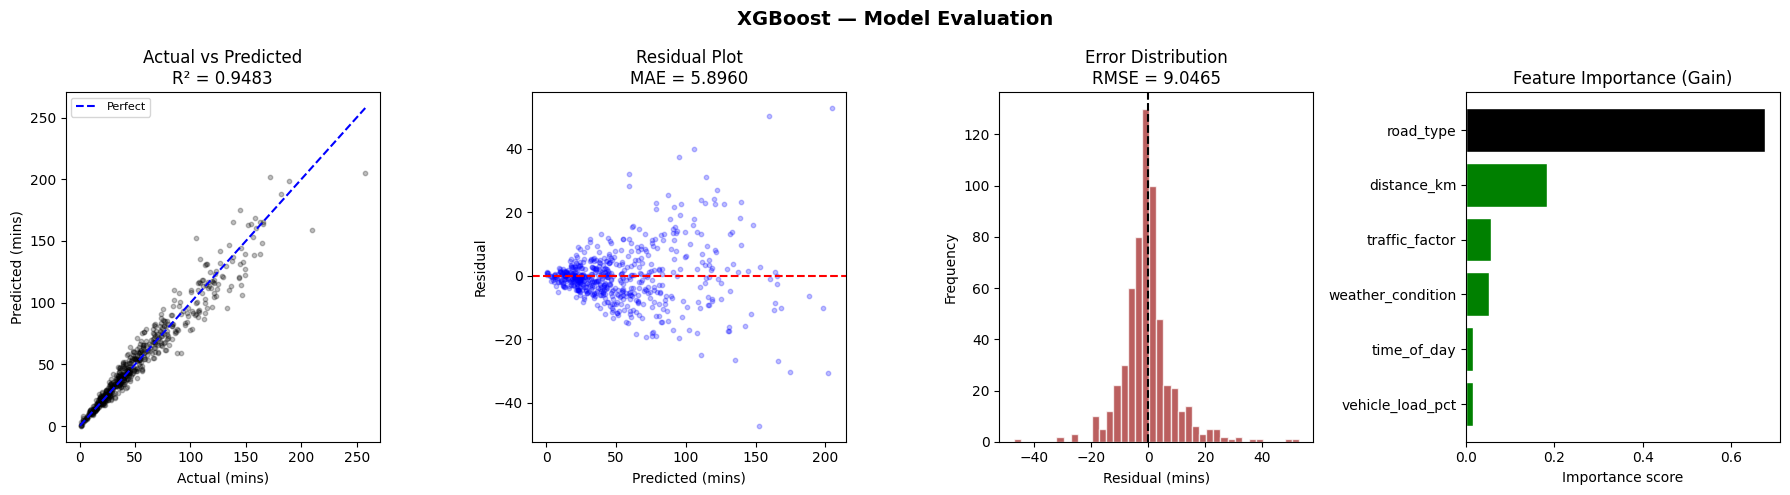

In [9]:
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
fig.suptitle("XGBoost — Model Evaluation", fontsize=14, fontweight="bold")

# Plot 1: Actual vs Predicted
ax = axes[0]
ax.scatter(y_test, y_pred, alpha=0.25, s=10, color="black")
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
ax.plot([min_val, max_val], [min_val, max_val], "b--", lw=1.5, label="Perfect")
ax.set_xlabel("Actual (mins)")
ax.set_ylabel("Predicted (mins)")
ax.set_title(f"Actual vs Predicted\nR² = {r2:.4f}")
ax.legend(fontsize=8)

# Plot 2: Residuals
residuals = y_test - y_pred
ax = axes[1]
ax.scatter(y_pred, residuals, alpha=0.25, s=10, color="blue")
ax.axhline(0, color="red", linestyle="--", lw=1.5)
ax.set_xlabel("Predicted (mins)")
ax.set_ylabel("Residual")
ax.set_title(f"Residual Plot\nMAE = {mae:.4f}")

# Plot 3: Residual distribution
ax = axes[2]
ax.hist(residuals, bins=40, color="brown", alpha=0.75, edgecolor="white")
ax.axvline(0, color="black", linestyle="--", lw=1.5)
ax.set_xlabel("Residual (mins)")
ax.set_ylabel("Frequency")
ax.set_title(f"Error Distribution\nRMSE = {rmse:.4f}")

# Plot 4: Feature importance
ax = axes[3]
colors = ["black" if i == 0 else "green"
          for i in range(len(importance_df))]
ax.barh(importance_df["Feature"], importance_df["Importance"],
        color=colors, edgecolor="white")
ax.set_xlabel("Importance score")
ax.set_title("Feature Importance (Gain)")
ax.invert_yaxis()

plt.tight_layout()
plt.savefig("xgboost_evaluation.png", dpi=150, bbox_inches="tight")
print("  Saved: xgboost_evaluation.png")
plt.show()

### SAVE THE MODEL

In [10]:

joblib.dump(model, "xgboost_model.pkl")

print("  Saved: xgboost_model.pkl")
print("  (No scaler needed — XGBoost is scale-invariant)")

print("\n" + "="*60)
print("  XGBOOST COMPLETE")
print(f"  MAE={mae:.4f}  RMSE={rmse:.4f}  R²={r2:.4f}")
print("="*60 + "\n")

  Saved: xgboost_model.pkl
  (No scaler needed — XGBoost is scale-invariant)

  XGBOOST COMPLETE
  MAE=5.8960  RMSE=9.0465  R²=0.9483

